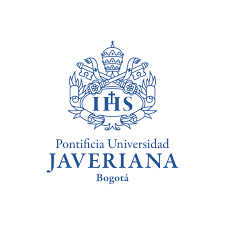

# **Pontificial Xaverian University**
## **Data Processment**
### **Big Data Processment**
**Date**: May 7th, 2026

**Autor**: Carlos Andrés Jr. Méndez Pachón

**Topic**: Introduction to Clasification Models

            - Spark server through Jupyter test
            - Exploration and data cleaning.
            - Clasification model deployment.

**Goals**:

    - Load Spark Session
    
    - Load Data from the bank
    
    - Data Understanding
    
    - Clean Data

    

In [1]:
## Import basic libraries
import os
import sys                             #---> Provides the interpreter access to some variables
import pandas as pd                    #---> For dataframes and plotting
import numpy as np                     #---> For mathematical operations
import matplotlib.pyplot as plt        #---> For visualization formatting
import seaborn as sns

## Specialized libraries import
import findspark                       #---> Locates Spark to add it to the python path
findspark.init()
from pyspark.sql import SQLContext, SparkSession, Row            #---> Session for SQL-based query environments
from pyspark import SparkContext, SparkConf     #---> PySpark context and configuration
from pyspark.sql import functions as F
from pyspark.sql.types import *

## Machine Learning libraries import
from pyspark.ml.feature import StringIndexer, OneHotEncoder   #-> Provides access to variable preparation functions for ML
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [2]:
configura = SparkConf()
configura.set("spark.scheduler.mode","FAIR")                                        #---> Required so that multiple users can access resources concurrently
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")  #---> Location of the .xml file for the fair scheduler configuration
configura.setMaster("spark://10.43.97.187:7077")                                    #---> Set and enforce the Master IP address for the configuration
configura.setAppName("Banca_MendezSPARK")                                           #---> Assigning the application name
sparkMendez = SparkSession.builder.config(conf=configura).getOrCreate()             #---> Creating the session
sparkMendez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 18:25:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## The dataset is imported via HDFS

In [3]:
## Accessing the csv data file within the cluster
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


In [4]:
## The data is accessed through the HDFS server of the user 10.195.34.34 via the port 9000
df00 = sparkMendez.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv") #---> The separator is specified
## First data visualization showing only the 5 first rows
df00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

In [5]:
## The identification of dataframe variables is performed.
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



- Todos los datos se encuentran en String
- Se debe cambiar las variables a tipo entero
- Se observa que la última columna es la ETIQUETA

In [6]:
## display the amount of data
print(f"The total data amount is: {df00.count()} registros")

The total data amount is: 45211 registros


In [7]:
# The following columns are changed to Integer
df01 = df00
df01 = df01.withColumn("age", df00.age.cast("int")) ## ---> The variable cast is performed in a dataset copy
df01 = df01.withColumn("balance", df00.balance.cast("int"))
df01 = df01.withColumn("day", df00.day.cast("int")) ## ---> From this point, a new copy is not made, but the same dataset is modified: "dfPy01"
df01 = df01.withColumn("duration", df00.duration.cast("int"))
df01 = df01.withColumn("campaign", df00.campaign.cast("int"))
df01 = df01.withColumn("pdays", df00.pdays.cast("int"))
df01 = df01.withColumn("previous", df00.previous.cast("int"))

df01.printSchema() ## ---> Display the Schema of data

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## Data identification and analysis
- Balance
- Risk of bias

In [8]:
total = df01.count() #-> Getting the total amount of data
df_Y = df01.groupBy("y").count()

auxPD = df_Y.withColumn("Percentage", df_Y["count"]*100/total) #-> Calculating percentage of "yes" and "no" to see if the data is balanced or no

auxPD.show()

[Stage 8:=============================>                             (1 + 1) / 2]

+---+-----+------------------+
|  y|count|        Percentage|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



## Analysis
- A serious imbalance has been identified in the target variable; therefore, decisions must be made to avoid bias.

- The minority category is "yes," representing approximately 11.6% of the data.

- The majority category is "no," representing approximately 88.3% of the data.
- Since the variable is binary, it is important to consider the potential bias. Therefore, care must be taken when developing prediction models.
- It is recommended to use classification models that account for this imbalance, such as logistic regression, or models specifically designed for imbalance, such as balanced random forest or easy ensemble.




In [9]:
## Data Statistics identification

for valor in df01.columns:

  df01.describe([valor]).show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             45211|
|   mean| 40.93621021432837|
| stddev|10.618762040975401|
|    min|                18|
|    max|                95|
+-------+------------------+



+-------+-------+
|summary|    job|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min| admin.|
|    max|unknown|
+-------+-------+



+-------+--------+
|summary| marital|
+-------+--------+
|  count|   45211|
|   mean|    NULL|
| stddev|    NULL|
|    min|divorced|
|    max|  single|
+-------+--------+

+-------+---------+
|summary|education|
+-------+---------+
|  count|    45211|
|   mean|     NULL|
| stddev|     NULL|
|    min|  primary|
|    max|  unknown|
+-------+---------+

+-------+-------+
|summary|default|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min|     no|
|    max|    yes|
+-------+-------+

+-------+------------------+
|summary|           balance|
+-------+------------------+
|  count|             45211|
|   mean|1362.2720576850766|
| stddev|3044.7658291685243|
|    min|             -8019|
|    max|            102127|
+-------+------------------+

+-------+-------+
|summary|housing|
+-------+-------+
|  count|  45211|
|   mean|   NULL|
| stddev|   NULL|
|    min|     no|
|    max|    yes|
+-------+-------+

+-------+-----+
|summary| loan|
+-------+-----+
|  count|45

In [10]:
col_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for col in col_cat:
    df01.groupBy(col).count().show()     #---> Display category balance

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

## **Variable Balance**
A certain imbalance is identified in the variables y (target), loan and default (does it have default credit?), in which the "no" category predominates in all 3 cases.

### **It requires to see in graphics the numeric variables**
- Every numeric variable is agroupated and the amount of occurrences in each group is graphicated

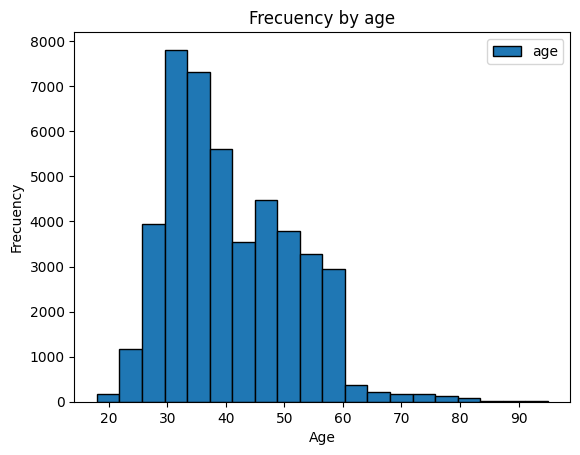

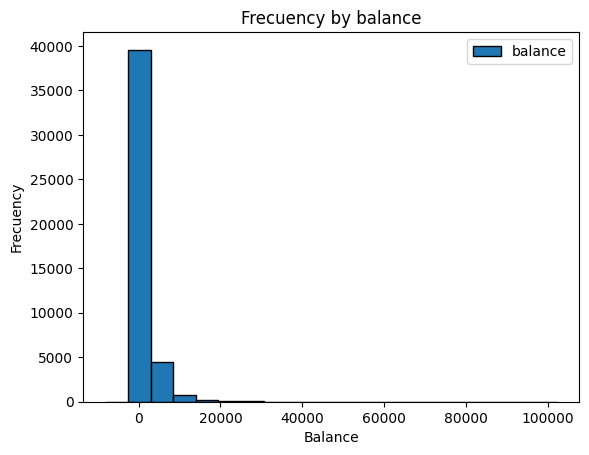

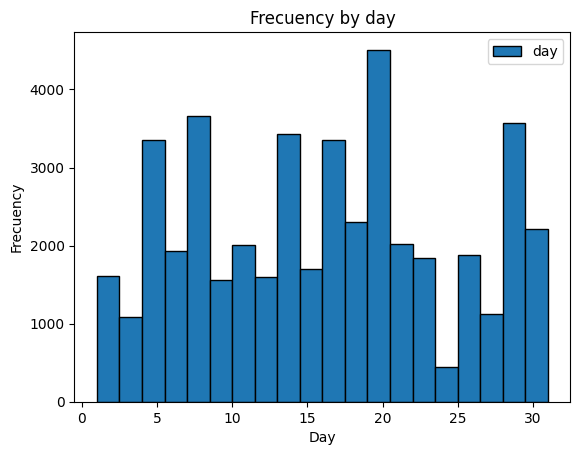

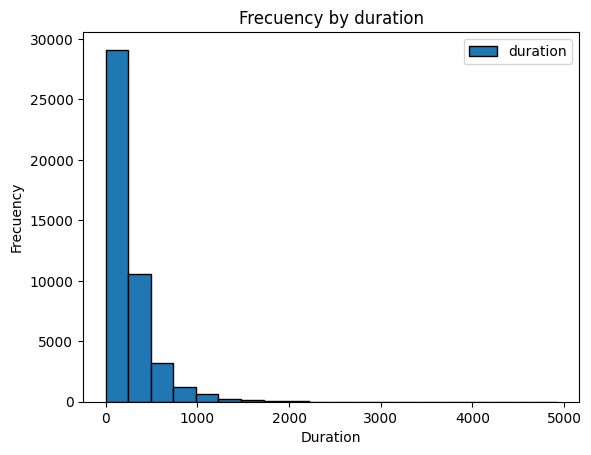

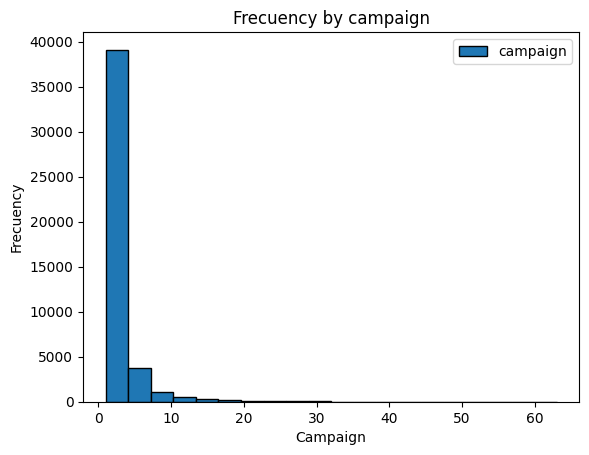

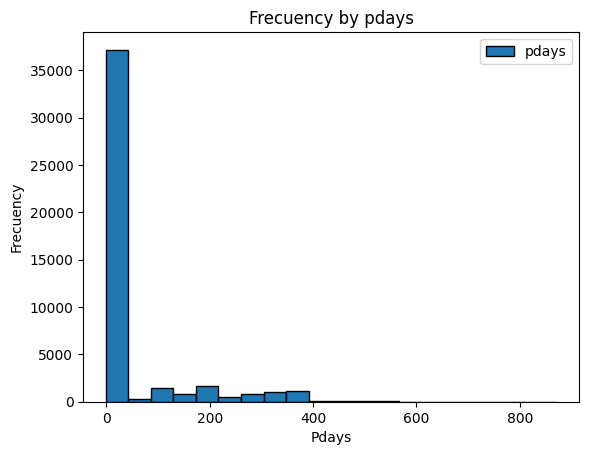

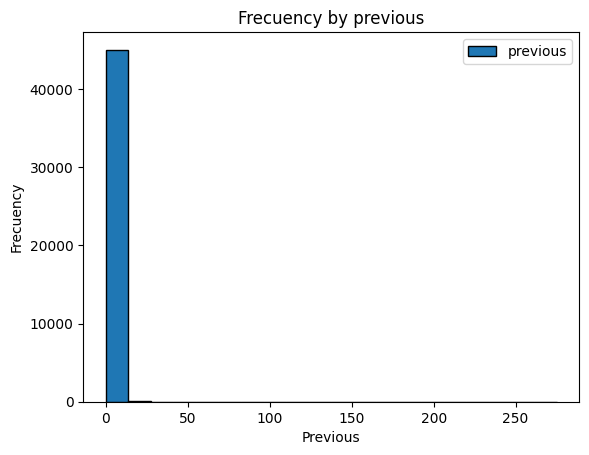

In [11]:
### The integer variables frecuency are graphicated

colInt= ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
for col_int in colInt:
    histGra = df01.select(col_int).toPandas()
    histGra.plot(kind='hist', bins=20, edgecolor='black')   #---> The graphic is set up considering the bins, type of graphic and color of separations
    plt.xlabel(col_int.capitalize())
    plt.ylabel("Frecuency")
    plt.title(f"Frecuency by {col_int}")

## **Graphic Analysis**
1. Frecuency by age
   
    A certain trend towards the middle (ages between 26 and 60 years) can be identified, taking the form of a Gaussian bell curve.
   
2. Frecuency by Balance

    It is identified that the average annual balance of the users is mostly 0, with only a few having a value slightly greater than 0 and less than 2000.

3. Frecuency by day

   Although the data appears to be well distributed by each day, it is identified that in a range of 23-25 aproximately there is lower frecuency than the other days

4. Frecuency by duration

   The data indicates that the majority of users does not stay more than 2000 seconds in the call. Is required to be cautious at the time of analyze this variable because of the description provided from the bank.

5. Frecuency by campaign

   The graph indicates that, there are many outlyers at the right side (it has to be analyzed and consider if those outliers can be deleted). Furthermore, a rapid drop in data means that the companie did not need to call the same user multiple times, wich is a good sign for the enterprise

6. Frecuency by pdays

   Although they may appear to be outliers, they cannot be easily eliminated, since, due to these seemingly outliers, there appear to be many to eliminate without any discrimination.

7. Frecuency by previous

   The graph indicates that there are few values outside the "0" value, it means that this value can be considered an outlier and will probably be deleted in the following steps. The majority of the data is located in the "0" value, indicating that the company didn't had any type of interaction with the client before the campaign.

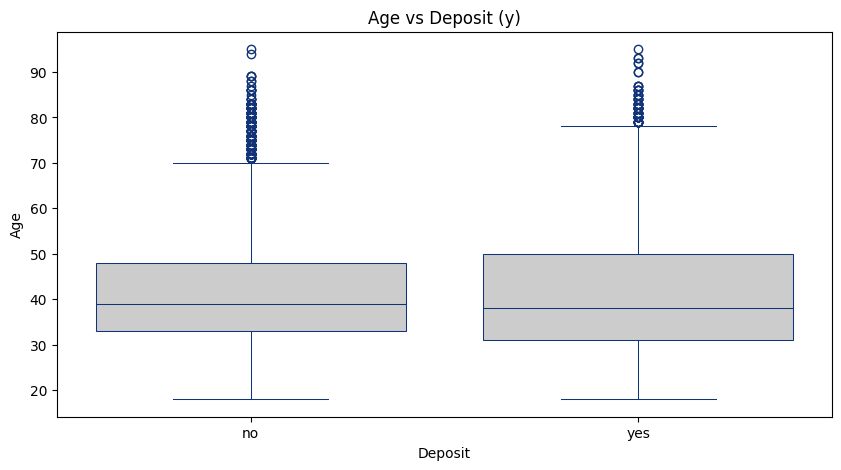

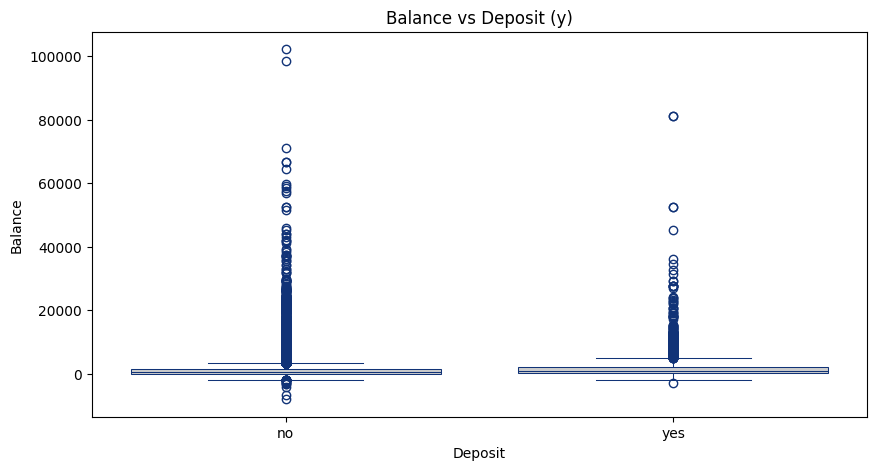

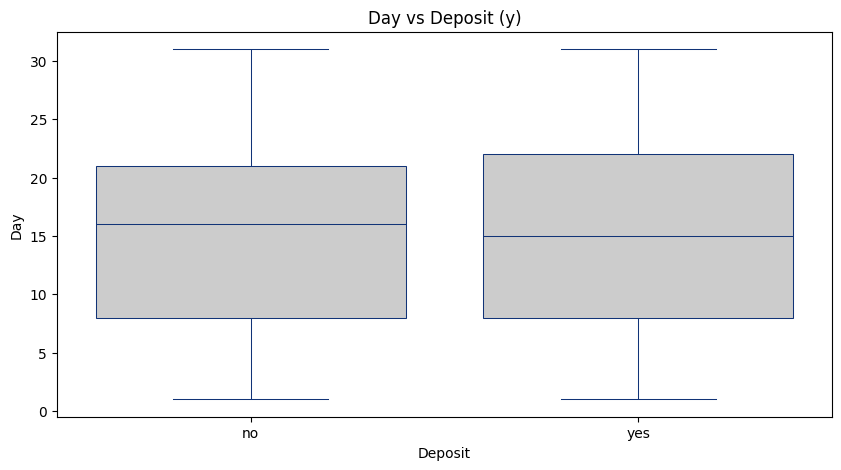

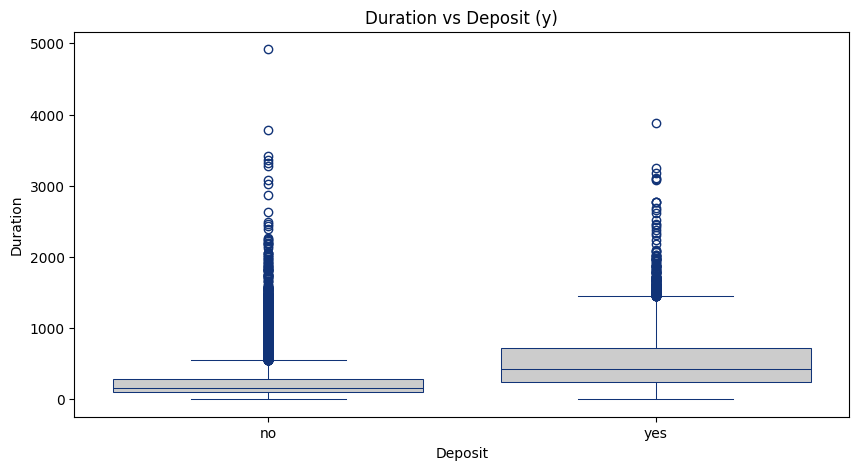

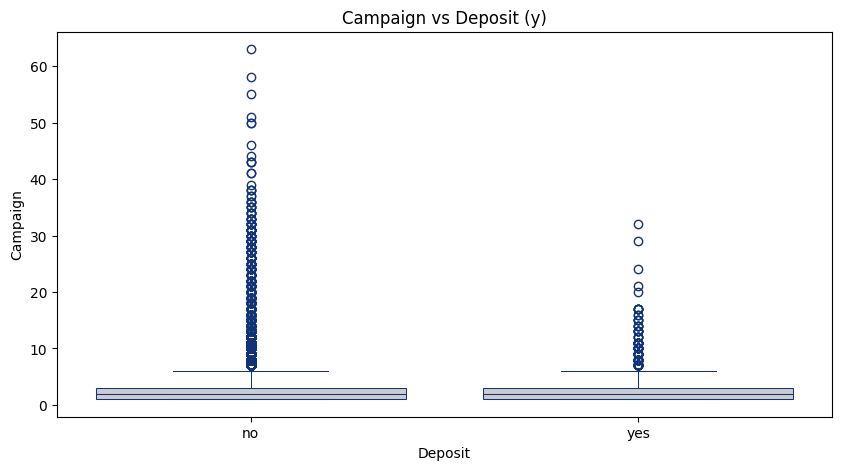

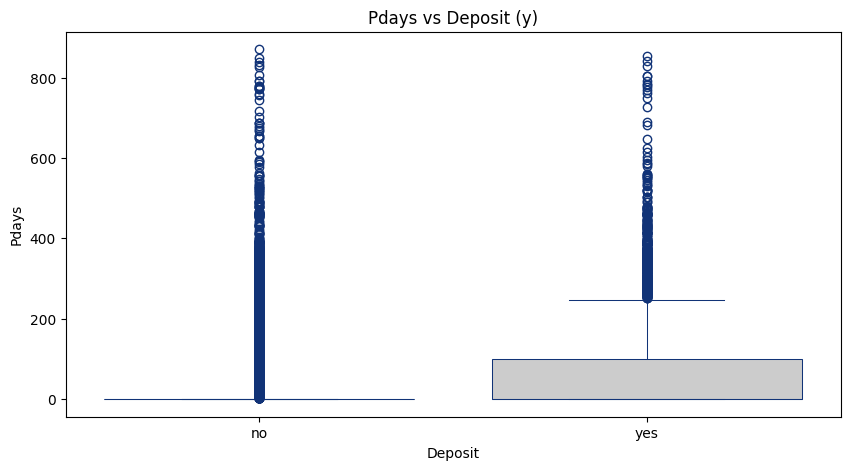

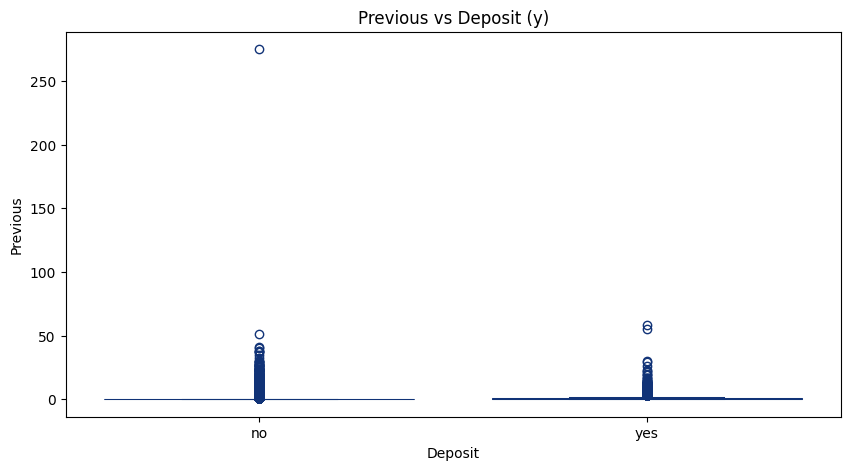

In [12]:
### The goal using this type of graphic is to notices tendencies and outlyeres of the variables

for col_int in colInt:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='y', y=col_int, color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
    plt.title(f"{col_int.capitalize()} vs Deposit (y)")
    plt.xlabel("Deposit")
    plt.ylabel(col_int.capitalize())
    plt.show()

### Analysis
This type of graphic is a great help to identify those outliers that can be deleted and those that can not. For example, if it is a few amount of values far from the box, it means that those values are possible candidates to be deleted. Dots far away from the top limit can be deleted too

While all graphics show outliers, there is one that does not, day vs deposit -> All users had been contacted between the 10th and 25th of the month

In [13]:
## It requires to change the target variable name
## Also, is needed to change to numeric values

dfauxNum = df01.select(colInt + ['y']) #---> Creating new dataset
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0)) #---> Changing to Integer 'y' values
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [14]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')

# Normalized and Scaling Vector
dfNumVector = assembler.transform(dfauxNum).select('features')

Text(0.5, 1.0, 'Correlation Matrix within numeric variables and y variable')

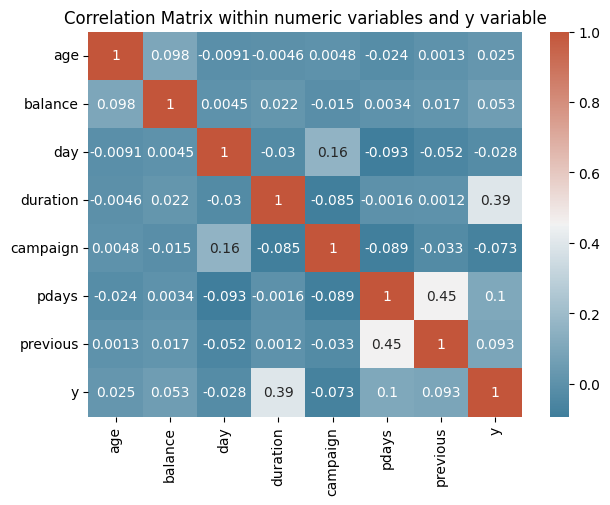

In [15]:
## Is graphed the correlation matrix
from pyspark.ml.stat import Correlation
corrMatrix = Correlation.corr(dfNumVector, 'features').head()

corrVector = corrMatrix[0].toArray()

## Is created a dataframe object using the previous Pearson Correlation array
dfCorrelation = pd.DataFrame(corrVector, columns = dfauxNum.columns, index=dfauxNum.columns)

cmapMendez = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapMendez)
plt.title('Correlation Matrix within numeric variables and y variable')

## Analysis
Is showed that pdays and previous can have correlation, introducing multicollinearity to a future model,  

Also, there is a strong correlation within y(has the client subscribed a term deposit?) and duration, according to the data source this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

In [16]:
## Is required to do a graphic about all parameters
colors = ['brown', 'lightblue']

#sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y', palette=colors)
#plt.show()

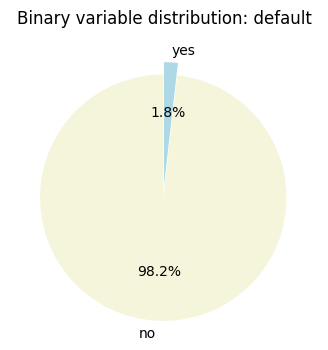

In [17]:
### Is required to graphic [Default, housing, loan] separately
# default
explode = (0.1, 0)
colors = ['beige', 'lightblue']
plt.figure(figsize=(5,4))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary variable distribution: default')
plt.ylabel('')
plt.show()
plt.show()


There is a notable dominance by the "no" category, the 98.2% of the users have not credit in default.

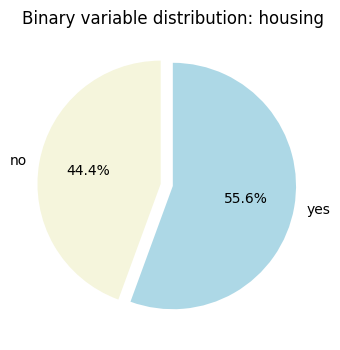

In [18]:
### Is required to graphic [Default, housing, loan] separately
# housing
explode = (0.1, 0)
colors = ['beige', 'lightblue']
plt.figure(figsize=(5,4))
cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary variable distribution: housing')
plt.ylabel('')
plt.show()
plt.show()

The 55.6% of the users has housing loan.

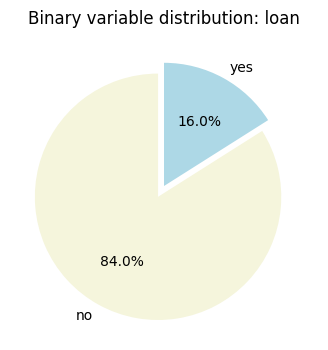

In [19]:
### Is required to graphic [Default, housing, loan] separately
# loan
explode = (0.1, 0)
colors = ['beige', 'lightblue']
plt.figure(figsize=(5,4))
cantBin = df01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Binary variable distribution: loan')
plt.ylabel('')
plt.show()
plt.show()

Only the 16% of the users have personal loan.

### Multidimensionals categorical variables

<Figure size 800x600 with 0 Axes>

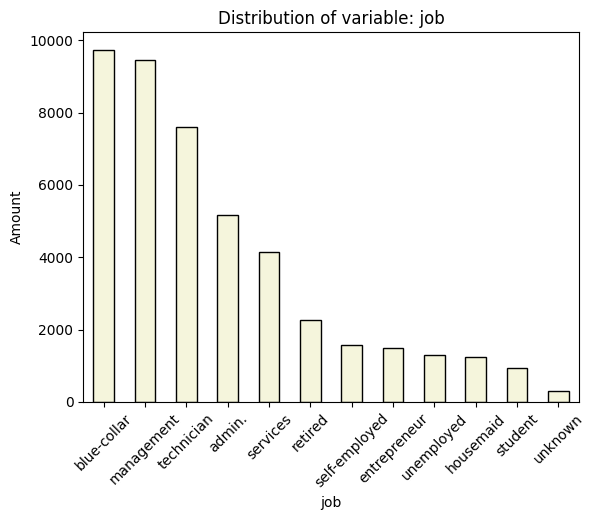

In [20]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#job
cantMulti = df01.groupBy('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('job')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: job')
plt.xticks(rotation=45)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

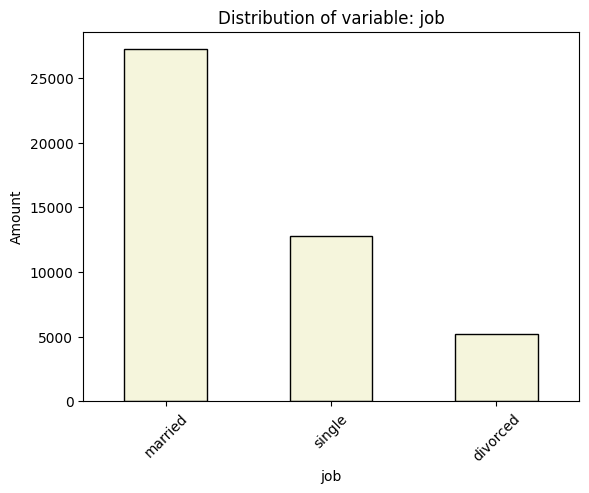

In [21]:
#marital
cantMulti = df01.groupBy('marital').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='marital', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('job')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: job')
plt.xticks(rotation=45)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

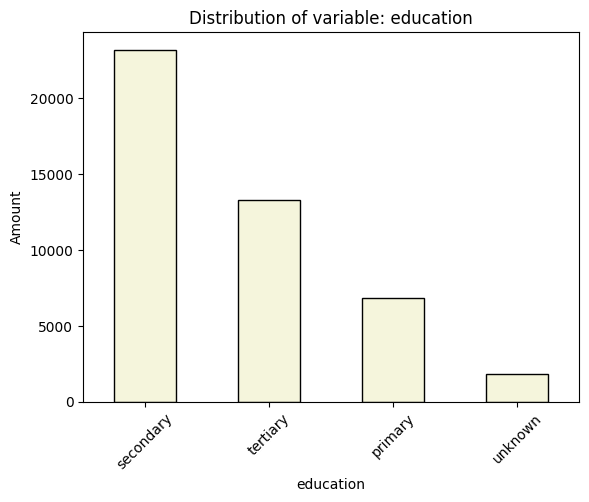

In [22]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#education
cantMulti = df01.groupBy('education').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='education', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('education')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: education')
plt.xticks(rotation=45)
plt.show

<Figure size 800x600 with 0 Axes>

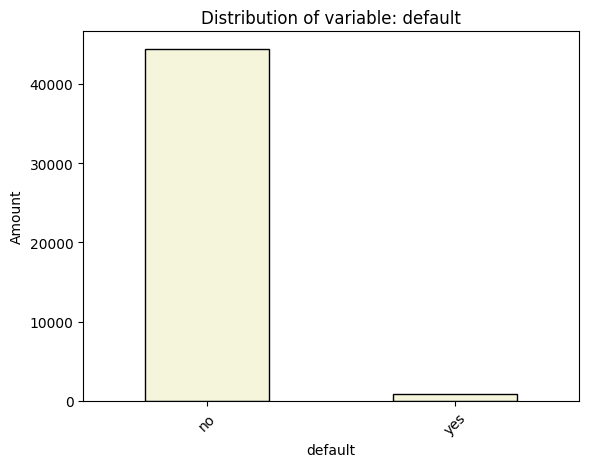

In [23]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#default
cantMulti = df01.groupBy('default').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='default', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('default')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: default')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

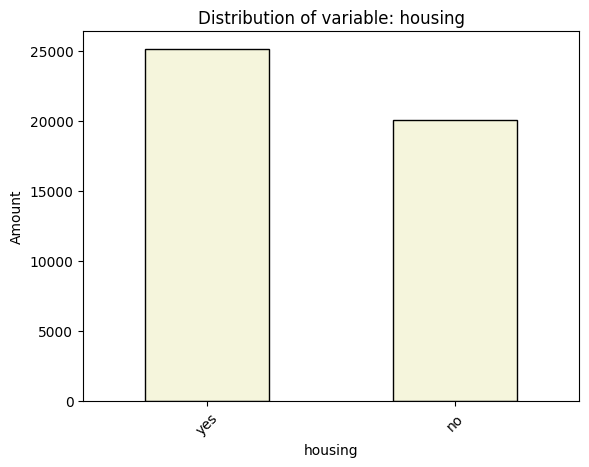

In [24]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#housing
cantMulti = df01.groupBy('housing').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='housing', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('housing')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: housing')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

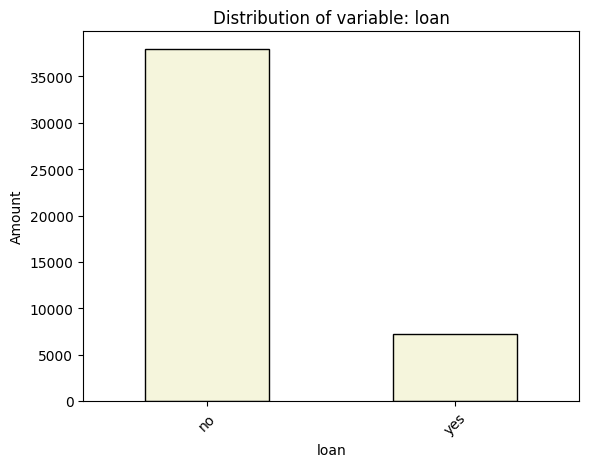

In [25]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#loan
cantMulti = df01.groupBy('loan').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='loan', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('loan')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: loan')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

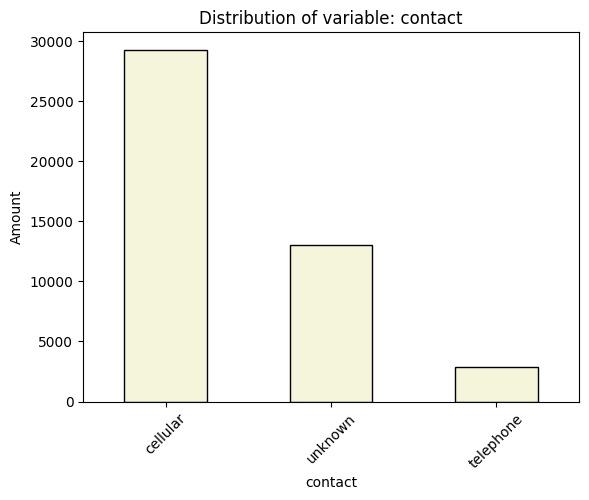

In [26]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#contact
cantMulti = df01.groupBy('contact').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='contact', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('contact')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: contact')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

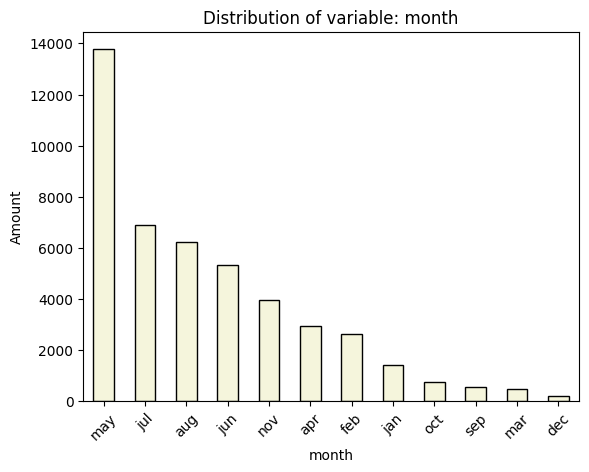

In [27]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#month
cantMulti = df01.groupBy('month').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='month', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('month')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: month')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

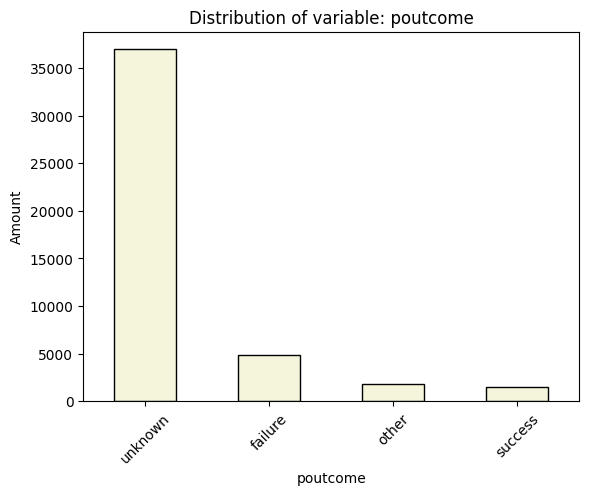

In [28]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#poutcome
cantMulti = df01.groupBy('poutcome').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('poutcome')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: poutcome')
plt.xticks(rotation=45)
plt.show()

<Figure size 800x600 with 0 Axes>

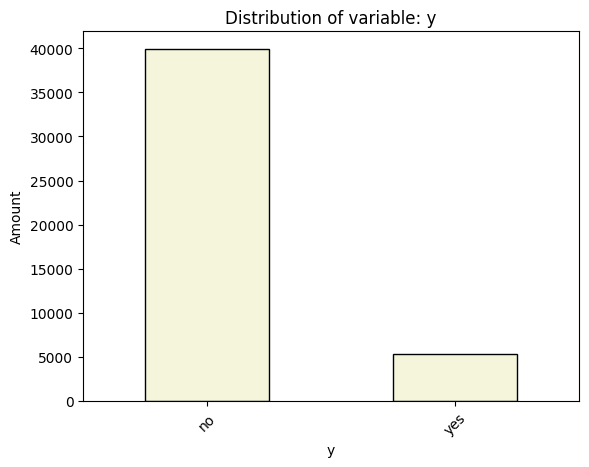

In [29]:
### Categorical variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
#y
cantMulti = df01.groupBy('y').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='y', y='count', legend=None, edgecolor='black', color='BEIGE')
plt.xlabel('y')
plt.ylabel('Amount')
plt.title(f'Distribution of variable: y')
plt.xticks(rotation=45)
plt.show()

Analysing the previous graph is created a hypotesis:

If the user is not a client of the bank (has not used any type of product (loan, housing loan, credit in default) probably they are not going to suscribe to a fixed term deposit

### Bar graphics agrupated by categorical variables in relation with the dependant variable "y" < fixed term deposit >

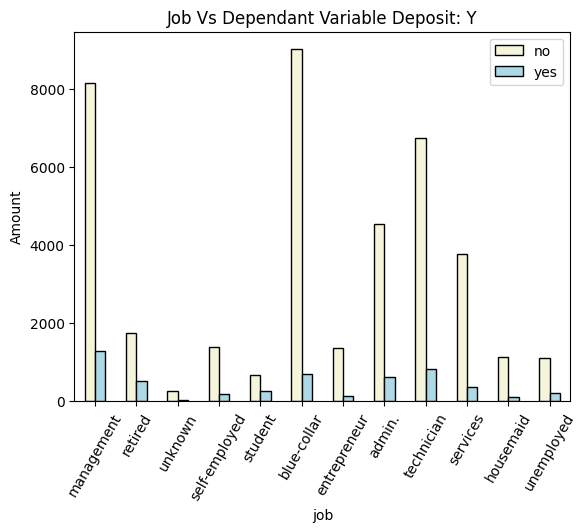

In [30]:
cratabJob=df01.crosstab('job','y').toPandas()
cratabJob.set_index('job'+'_y').plot(kind="bar", color = ['beige', 'lightblue'], edgecolor='black')
plt.xlabel('job')
plt.ylabel('Amount')
plt.title('Job Vs Dependant Variable Deposit: Y')
plt.xticks(rotation = 60)
plt.show()

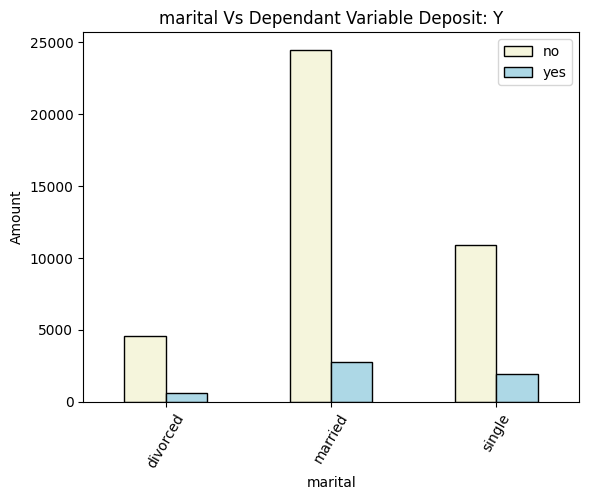

In [31]:
cratabJob=df01.crosstab('marital','y').toPandas()
cratabJob.set_index('marital'+'_y').plot(kind="bar", color = ['beige', 'lightblue'], edgecolor='black')
plt.xlabel('marital')
plt.ylabel('Amount')
plt.title('marital Vs Dependant Variable Deposit: Y')
plt.xticks(rotation = 60)
plt.show()

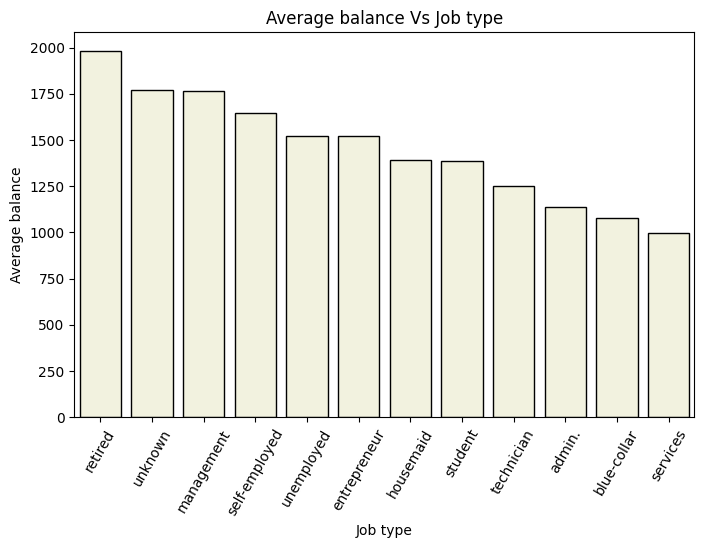

In [32]:
## Is made a graphic for numeric variables

montoTrabajo = df01.groupby('job').agg({'balance':'mean'}).toPandas()
montoTrabajo = montoTrabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=montoTrabajo, x='job', y='avg(balance)', color = 'beige', edgecolor = 'black')
plt.xlabel('Job type')
plt.ylabel('Average balance')
plt.title('Average balance Vs Job type')
plt.xticks(rotation=60)
plt.show()

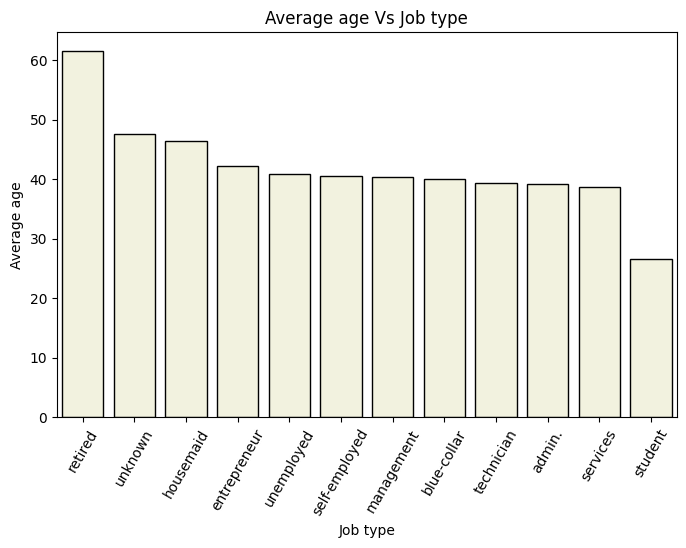

In [33]:
## Is made a graphic for numeric variables

montoTrabajo = df01.groupby('job').agg({'age':'mean'}).toPandas()
montoTrabajo = montoTrabajo.sort_values('avg(age)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=montoTrabajo, x='job', y='avg(age)', color = 'beige', edgecolor = 'black')
plt.xlabel('Job type')
plt.ylabel('Average age')
plt.title('Average age Vs Job type')
plt.xticks(rotation=60)
plt.show()

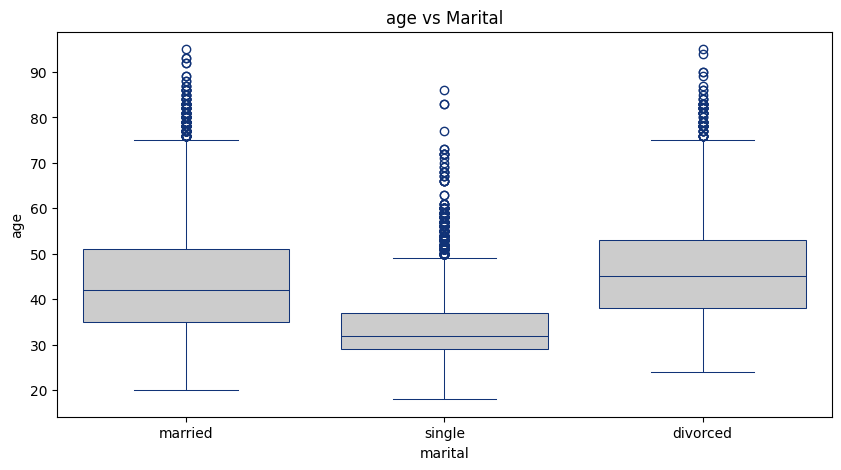

In [34]:
### The goal using this type of graphic is to notices tendencies and outlyeres of the variables
plt.figure(figsize=(10,5))
sns.boxplot(x='marital', y='age', color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.title(f"age vs Marital")
plt.xlabel("marital")
plt.ylabel('age')
plt.show()

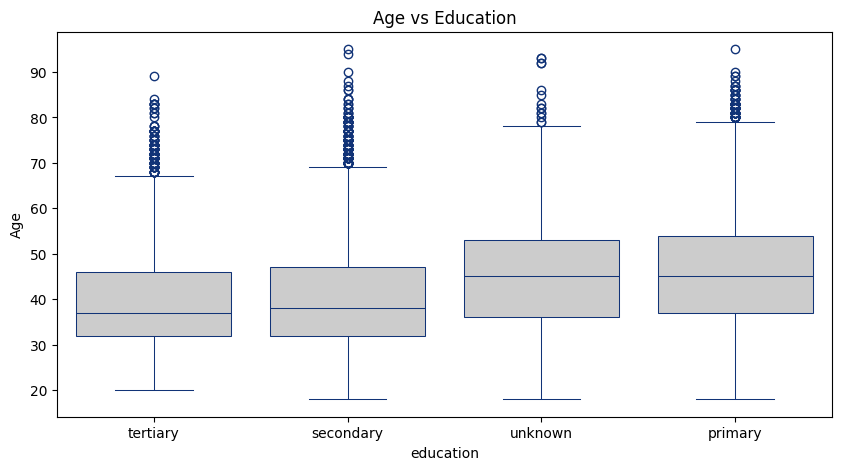

In [35]:
### The goal using this type of graphic is to notices tendencies and outlyeres of the variables
plt.figure(figsize=(10,5))
sns.boxplot(x='education', y='age', color=".8", linecolor="#137", linewidth=0.75, data=df01.toPandas())
plt.title(f"Age vs Education")
plt.xlabel("education")
plt.ylabel('Age')
plt.show()

## Age graphics analysis
with the help of the previous two graphics, the age ranges are identified: Ages between 30 and 55. Although, there are some outliers that represent users between 70 and 100 years old. 

In [36]:
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} null values")

'age' : 0 null values
'job' : 0 null values
'marital' : 0 null values
'education' : 0 null values
'default' : 0 null values
'balance' : 0 null values
'housing' : 0 null values
'loan' : 0 null values
'contact' : 0 null values
'day' : 0 null values
'month' : 0 null values
'duration' : 0 null values
'campaign' : 0 null values
'pdays' : 0 null values
'previous' : 0 null values
'poutcome' : 0 null values
'y' : 0 null values


## Data preparation

In [37]:
noPdays = df01.filter(F.col('pdays') == -1).count()

porcNoPdays = (noPdays/total)*100
print(f"Percentage of customers not previously contacted: {porcNoPdays:.2f}%")

# Pdays will be deleted because of the multicollinearity and de possible bias that the variable can introduce

Percentage of customers not previously contacted: 81.74%


In [38]:
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



In [39]:
## Is required to eliminate those outliers: data from 30 and more.
# Is calculate the amount of registers that are in this range of data.
limitePrevio = 30

cantLimitePrevio = df01.filter(F.col('previous') > limitePrevio).count()

print(f"Amount of data above 30 contacts: {cantLimitePrevio}")

Amount of data above 30 contacts: 12


In [40]:
df02 = df01.filter(F.col('previous') <= 30)

In [41]:
# Is eliminated "pdays"
df03 = df02.drop('pdays')

In [42]:
dfNoDependant = df03.filter(df03['y'] == 'no')
dfYesDependant = df03.filter(df03['y'] == 'yes')

nNo = dfNoDependant.count()

dfOverSampleYes = dfYesDependant.sample(True, nNo/dfYesDependant.count(), seed=42)

df04 = dfNoDependant.union(dfOverSampleYes)

In [43]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [44]:
for columna in df04.columns:
    cantNulos = df04.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} null values")

'age' : 0 null values
'job' : 0 null values
'marital' : 0 null values
'education' : 0 null values
'default' : 0 null values
'balance' : 0 null values
'housing' : 0 null values
'loan' : 0 null values
'contact' : 0 null values
'day' : 0 null values
'month' : 0 null values
'duration' : 0 null values
'campaign' : 0 null values
'previous' : 0 null values
'poutcome' : 0 null values
'y' : 0 null values


In [45]:
totalNw = df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("%", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|                %|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [46]:
print(df01.count())
print(df04.count())

45211
80201


## Characteristics codification and vector creation

### [One Hot Encoding](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.OneHotEncoder.html#onehotencoder)

One-hot encoding is a common technique in machine learning, particularly when dealing with categorical variables. It involves representing each category as a binary vector. In this process, a binary vector is created for each unique category,with all elements set to zero except for the one correspondingto the category of a given observation, which is set to one.This results in a matrix of binary vectors representing thecategorical variables in the dataset. One-hot encoding is widely used in tasks like classification, where numerical input is required by machine learning algorithms such as logistic regression or neural networks (Ivor, 2024)

For example: Marital -> married, single and divorced

One Hot Encoding creates three differents columns referring to the three categorys of 'Job', this is how it looks:
married: [1, 0, 0]
single: [0, 1, 0]
divorced: [0, 0, 1]

In [47]:
# One Hot Encoding
col_cat = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

stage = []

for col in col_cat:
    indexer = StringIndexer(inputCol=col, outputCol=col+'x')

    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[col + '_oneHot'])
    stage += [indexer, encoder]

In [48]:
lab = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')

stage += [lab]

In [49]:
NumCol = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

ensInput = [c + '_oneHot' for c in col_cat] + NumCol

ensInput

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

### [Vector Assembler](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.html) 
Vector Assembler is the function of pySpark that enables the user to convert the category columns to a DataFrame of only numeric indexers. Many machine learning algorithms can not work with the presence of character variables, so, vector assembler solve this problem by assigning a unique indexer to every different string value of the input column and assigning it to a new output column of integer indexes

In [50]:
ensVector = VectorAssembler(inputCols=ensInput, outputCol='features')
stage += [ensVector]

In [51]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages=stage)
pipelineModel = pipeline.fit(df04)

pipelineModel.write().overwrite().save(path='pipeModel')
model = pipelineModel.transform(df04)

In [52]:
model.show(5)

26/05/25 18:27:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [53]:
df05 = model.select("label", "features")
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [54]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [55]:
df05.write.mode("overwrite").parquet("output.parquet")

In [56]:
!pwd

/home/estudiante/Carlos


In [57]:
#df06 = sparkMendez.read.parquet("output.parquet")
#df06.show(2)

# Model creation

In [58]:
# The dataset is divided in train and test data

trainData, testData = df05.randomSplit([.8, .2], seed=4321)

print(f"Train data amount: {trainData.count()}")
print(f"Test data amount: {testData.count()}")

Train data amount: 64234


[Stage 426:==========================================>              (3 + 1) / 4]

Test data amount: 15967


In [59]:
# The test data balance is verified 

distTest = testData.groupBy("label").count()

distTest = distTest.withColumn("%", distTest["count"]*100/testData.count())
distTest.show()

[Stage 432:============================>                            (2 + 2) / 4]

+-----+-----+-----------------+
|label|count|                %|
+-----+-----+-----------------+
|  1.0| 7935|49.69624851255715|
|  0.0| 8032|50.30375148744285|
+-----+-----+-----------------+



In [60]:
# The train data balance is verified 

distTrain = trainData.groupBy("label").count()

distTrain = distTrain.withColumn("%", distTrain["count"]*100/trainData.count())
distTrain.show()

[Stage 438:============================>                            (2 + 2) / 4]

+-----+-----+-----------------+
|label|count|                %|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



Data is balanced and ready to modelling

In [61]:
## Confusion matrix function

def plotConfusionMat(confMatrix, subtitle):
    confMatrixPandas = confMatrix.toPandas() #---> Dataframe to pandas
    confMatrixPivot = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0) #---> Restructuration to create confusion matrix 
    plt.figure(figsize=(5,4))
    sns.heatmap(confMatrixPivot, annot=True, fmt='g')
    plt.suptitle(subtitle)
    plt.title('Confusion Matrix')
    plt.xlabel('Label prediction')
    plt.ylabel('Label')
    plt.show()

In [62]:
# ROC function

def plotROC(predictions, rocMetric, subtitle):
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1]) # Getting the probabilities for the positive class
    labels = predictions.select('label').rdd.map(lambda row: row['label']) #---> getting true labels
    fpr, tpr, thesholds = roc_curve(labels.collect(), probs.collect()) #---> calculating ROC using probabilities of the true labels
    
    # Graphicating ROC curve
    plt.figure(figsize=(8,4))
    plt.plot(fpr, tpr, color='lightblue', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='beige', lw=2, linestyle='--')
    plt.xlabel('False Positive Proportion')
    plt.ylabel('True Positive Proportion')
    plt.title('ROC curve')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()

In [63]:
def plotROC_SVM(predictions, rocMetric, subtitle):
    # Check if 'probability' column exists; if not, fallback to 'rawPrediction'
    if 'probability' in predictions.columns:
        # For Logistic Regression / Trees (index 1 is the positive class probability)
        probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    else:
        # For SVM (index 1 is the raw distance score/margin for the positive class)
        probs = predictions.select('rawPrediction').rdd.map(lambda row: row['rawPrediction'][1])
        
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())

     # Graphicating ROC curve
    plt.figure(figsize=(8,4))
    plt.plot(fpr, tpr, color='grey', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='lightblue', lw=2, linestyle='--')
    plt.xlabel('False Positive Proportion')
    plt.ylabel('True Positive Proportion')
    plt.title('ROC curve')
    plt.suptitle(subtitle)
    plt.legend(loc='lower right')
    plt.show()


# [Performance Metrics](https://www.ibm.com/es-es/think/topics/model-performance#:~:text=La%20precisi%C3%B3n%20es%20la%20proporci%C3%B3n,se%20predicen%20incorrectamente%20como%20positivos.):
Precision: Precision is the proportion of positive predictions that are actual positives. A machine learning model with high precision can minimize false positives

Recall: Recall quantifies the number of true positives—the actual correct predictions. It’s also known as the sensitivity rate or true positive rate 

F1: The F1 score is the harmonic mean of recall and precision, blending both metrics into a single one. It considers the two measures to be of equal weight to balance out any false positives or false negatives.

Accuracy: Accuracy is calculated as the number of correct predictions divided by the total number of predictions

## First model: [Linear Regression](https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-regression)
#### - **Trained object creation**: LRmodel

In [64]:
from pyspark.ml.classification import LogisticRegression
LRinstance = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

# Model fitting using Train data 
LRmodel = LRinstance.fit(trainData)

26/05/25 18:27:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

In [65]:
# Test data predictions
predLR = LRmodel.transform(testData)
predLR.select("label","prediction", "probability").show(5)

[Stage 454:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828945...|
|  0.0|       0.0|[0.92534178616341...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



In [66]:
evaluatorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

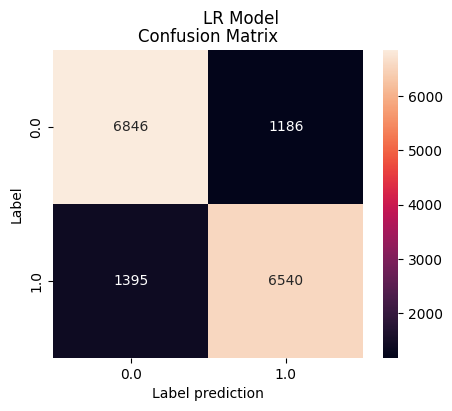

[Stage 464:==========================================>              (3 + 1) / 4]

Performance metrics results: LR Model
Precision: 0.839 
Recall: 0.838 
F1 score: 0.838 
Accuracy: 0.838


In [67]:
firstModel = "LR Model"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixLR, firstModel)

# Calculus of the model LR metrics using the multiclass evaluator
accuracyLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "accuracy"})
precisionLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "weightedPrecision"})
recallLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluatorLR.evaluate(predLR, {evaluatorLR.metricName: "f1"})

print(f"Performance metrics results: LR Model")
print(f"Precision: {round(precisionLR, 3)} ")
print(f"Recall: {round(recallLR, 3)} ")
print(f"F1 score: {round(f1ScoreLR, 3)} ")
print(f"Accuracy: {round(accuracyLR, 3)}")

0.9142824574418145
areaUnderROC


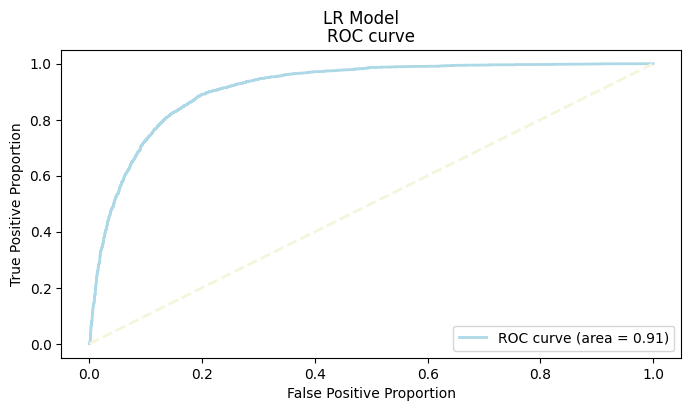

In [68]:
evaluatorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Is calculated and showed the ROC curve
rocLR = evaluatorBinLR.evaluate(predLR)
print(rocLR)
print(evaluatorBinLR.getMetricName())

plotROC(predLR,rocLR, firstModel)

## Evaluation: 
This model has an exceptional performance, all four metrics are above 0.83 values, what means it is capable to idendtify false positives and false negative 83 of 100 cases. However, there are some recommendations:

Define priority: In bank context is more needed to identify yes label or no label?

Try feature engineering or variable interactions to reduce bias

Finally, the area under ROC and ROC curve indicate that the model has excepcional capacity to detect false positive and the sharp rise of the graphic indicates a notable sensitivity (true positive) in the model.

Why area under ROC is so high and f1 not?: decision threshold -> F1 score fixate a decision threshold of 0.5, however, ROC curve evaluates all decision threshold from 0 to 1 (0.1 by 0.1)

# Second Model: [Decision Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.DecisionTreeClassifier.html#)

In [69]:
from pyspark.ml.classification import DecisionTreeClassifier
DTinstance = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# # Model fitting using Train data 
modelDT = DTinstance.fit(trainData)

In [70]:
# Test data prediction
predDT = modelDT.transform(testData)
# The first 5 predictions are showed
predDT.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.90950613759634...|
|  0.0|       0.0|[0.90950613759634...|
|  0.0|       0.0|[0.90950613759634...|
+-----+----------+--------------------+
only showing top 5 rows



In [71]:
evaluatorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

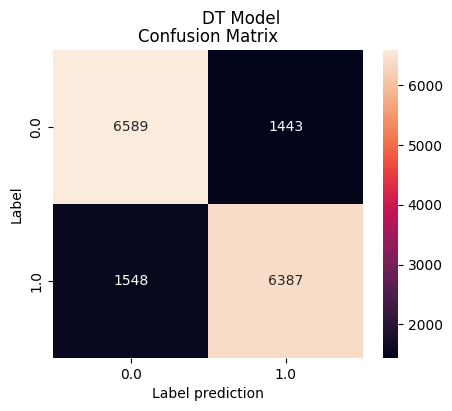

[Stage 503:==========================================>              (3 + 1) / 4]

Performance metrics results: Decision tree Model
Precision: 0.813
Recall:    0.813 
Accuracy:  0.813 
f1Score:  0.813 


In [72]:
# Confusion matrix is created using test data.
secondModel = "DT Model"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixDT, secondModel)

# calculation of the model DT metrics using the multiclass evaluator
accuracyDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "accuracy"})
precisionDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedPrecision"})
recallDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluatorDT.evaluate(predDT, {evaluatorDT.metricName: "f1"})

# Metrics are showed
print(f"Performance metrics results: Decision tree Model")
print(f"Precision: {round(precisionDT,3)}")
print(f"Recall:    {round(recallDT,3)} ")
print(f"Accuracy:  {round(accuracyDT,3)} ")
print(f"f1Score:  {round(f1ScoreDT,3)} ")

0.696921035141099
areaUnderROC


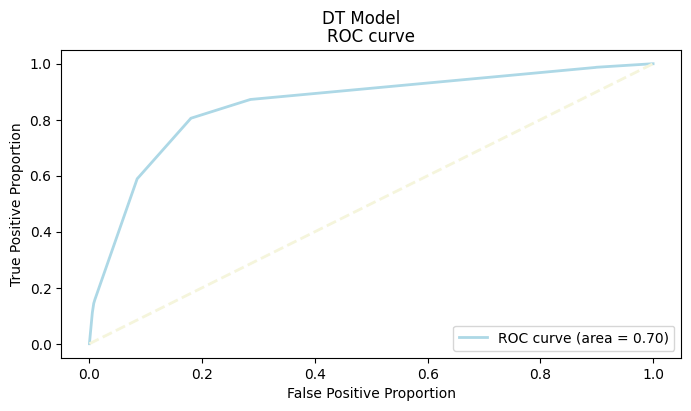

In [73]:
evaluatorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Is calculated and showed the ROC curve
rocDT = evaluatorBinDT.evaluate(predDT)
print(rocDT)
print(evaluatorBinDT.getMetricName())

plotROC(predDT,rocDT, secondModel)

## Evaluation: 
This model has an exceptional performance, all four metrics are above 0.817 values, what means it is capable to idendtify false positives and false negative 81.7 of 100 cases. However, there are some recommendations:

Define priority: In bank context is more needed to identify yes label or no label?

Try feature engineering or variable interactions to reduce bias

Linear regression still better.

Finally, the area under ROC and ROC curve indicate that the model has acceptable capacity to detect false positive and the sharp rise of the graphic indicates a notable sensitivity (true positive) in the model.

Why area under ROC is low and the others 4 metrics not?: The way decision tree calculates probabilities is through the final leaves. If the DT model has not enough leaves, area under ROC will be lower than expected.

To improve area under ROC is recomendated to change the maxDepth parameter.

# Third Model: [Gradient Boosted Tree](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.GradientBoostedTrees.html#)

In [74]:
from pyspark.ml.classification import GBTClassifier
GBTinstance = GBTClassifier(labelCol= 'label', featuresCol="features")

# model fitting using train data
modelGBT = GBTinstance.fit(trainData)

In [75]:
# Test data predictions
predGBT = modelGBT.transform(testData)
# the first 5 predictions of GBT model are showed
predGBT.select("label", "prediction", "probability").show(5)

[Stage 722:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.86369916600890...|
|  0.0|       0.0|[0.85919448293132...|
|  0.0|       0.0|[0.91528299443128...|
|  0.0|       0.0|[0.94227042635285...|
|  0.0|       0.0|[0.94203303892780...|
+-----+----------+--------------------+
only showing top 5 rows



In [76]:
evaluatorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

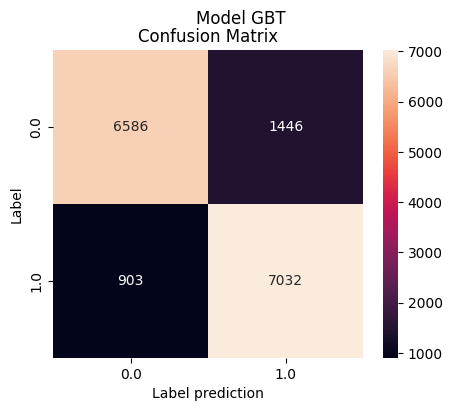

[Stage 732:==========================================>              (3 + 1) / 4]

Performance metrics results: Gradient Boosting Tree Model
Precision: 0.855 
Recall:    0.853 
Accuracy:  0.853 
f1Score:  0.853 


In [77]:
# Confusion matrix is created
thirdModel = "Model GBT"
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixGBT, thirdModel)

# Model GBT metrics are calculated
accuracyGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "accuracy"})
precisionGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedPrecision"})
recallGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "weightedRecall"})
f1ScoreGBT = evaluatorGBT.evaluate(predGBT, {evaluatorGBT.metricName: "f1"})

# 
print(f"Performance metrics results: Gradient Boosting Tree Model")
print(f"Precision: {round(precisionGBT,3)} ")
print(f"Recall:    {round(recallGBT,3)} ")
print(f"Accuracy:  {round(accuracyGBT,3)} ")
print(f"f1Score:  {round(f1ScoreGBT,3)} ")

0.9258454995393348
areaUnderROC


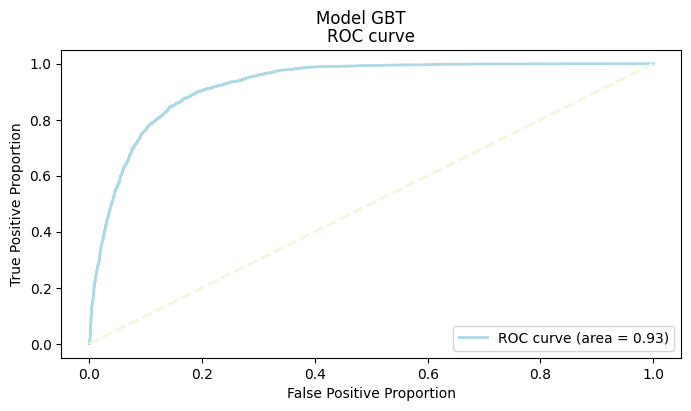

In [78]:
evaluatorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC curve is calculated and showed
rocGBT = evaluatorBinGBT.evaluate(predGBT)
print(rocGBT)
print(evaluatorBinGBT.getMetricName())

plotROC(predGBT,rocGBT,thirdModel)

## Evaluation: 
This model has an exceptional performance, all four metrics are above 0.854 values, what means it is capable to identify false positives and false negative 85.4 of 100 cases. However, there are some recommendations:

Define priority: In bank context is more needed to identify yes label or no label?

Try feature engineering or variable interactions to posible reduce bias

This is the best model at the moment.

Finally, the area under ROC and ROC curve indicate that the model has excepcional capacity to detect false positive and the sharp rise of the graphic indicates a notable sensitivity (true positive) in the model.

Why area under ROC is so high and f1 not?: decision threshold -> F1 score fixate a decision threshold of 0.5, however, ROC curve evaluates all decision threshold from 0 to 1 (0.1 by 0.1)

The model has almost the same capacity to detect false positive and false negative. 

# Fourth Model: [Random Forest](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.tree.RandomForest.html#)

In [79]:
from pyspark.ml.classification import RandomForestClassifier
RFinstance = RandomForestClassifier(labelCol= 'label', featuresCol="features")

# Model fitting using train data
modelRF = RFinstance.fit(trainData)

In [80]:
# test data prediction
predRF = modelRF.transform(testData)
# The first 5 predictions are showed
predRF.select("label", "prediction", "probability").show(5)

[Stage 761:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.62387002585501...|
|  0.0|       0.0|[0.55903791123019...|
|  0.0|       0.0|[0.77315243752126...|
|  0.0|       0.0|[0.80861063841478...|
|  0.0|       0.0|[0.76509058590115...|
+-----+----------+--------------------+
only showing top 5 rows



In [81]:
evaluatorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

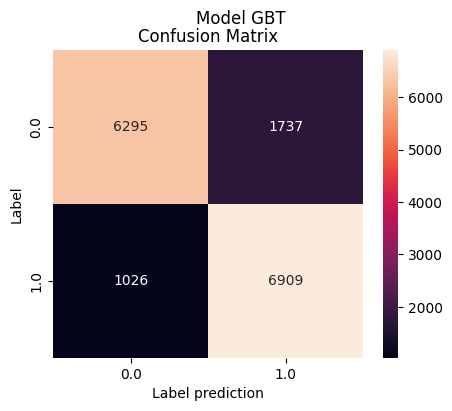

Performance metrics results: Random Forest Model
Precision: 0.83 
Recall:    0.827 
Accuracy:  0.827 
f1Score:  0.827 


In [82]:
# Confusion Matrix is created
fourthModel = "Model RF"
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixRF, thirdModel)

# Metrics calculation
accuracyRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "accuracy"})
precisionRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedPrecision"})
recallRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "weightedRecall"})
f1ScoreRF = evaluatorRF.evaluate(predRF, {evaluatorRF.metricName: "f1"})

print(f"Performance metrics results: Random Forest Model")
print(f"Precision: {round(precisionRF,3)} ")
print(f"Recall:    {round(recallRF,3)} ")
print(f"Accuracy:  {round(accuracyRF,3)} ")
print(f"f1Score:  {round(f1ScoreRF,3)} ")

0.8982968017658415
areaUnderROC


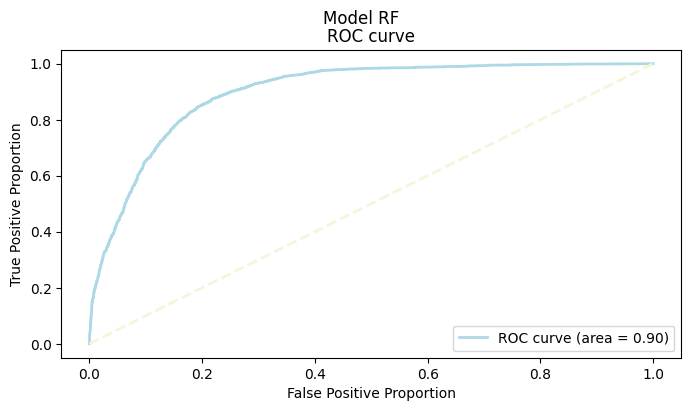

In [83]:
evaluatorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Roc curve is calculated and showed
rocRF = evaluatorBinRF.evaluate(predRF)
print(rocRF)
print(evaluatorBinRF.getMetricName())

plotROC(predRF,rocRF,fourthModel)

## Evaluation: 
This model has an exceptional performance, all four metrics are above 0.817 values, what means it is capable to idendtify false positives and false negative 81.7 of 100 cases. However, there are some recommendations:

Define priority: In bank context is more needed to identify yes label or no label?

Try feature engineering or variable interactions to reduce bias

Gradient Boosted Tree still better.

Finally, the area under ROC and ROC curve indicates that the model has acceptable capacity to detect false positive and the sharp rise of the graphic indicates a notable sensitivity (true positive) in the model.

# Fifth Model: [Support Vector Machine](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.classification.SVMModel.html)

In [84]:
from pyspark.ml.classification import LinearSVC
SVMinstance = LinearSVC(labelCol= 'label', featuresCol="features")

# Model fitting using train data
modelSVM = SVMinstance.fit(trainData)

In [85]:
predSVM = modelSVM.transform(testData)
# The first 5 predictions are showed.
predSVM.select("label", "prediction", "rawprediction").show(5)

[Stage 1010:>                                                       (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawprediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.91426429025163...|
|  0.0|       0.0|[0.73536210621743...|
|  0.0|       0.0|[0.94969728692479...|
|  0.0|       0.0|[1.77054047726010...|
|  0.0|       0.0|[1.55226657880525...|
+-----+----------+--------------------+
only showing top 5 rows



In [86]:
evaluatorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

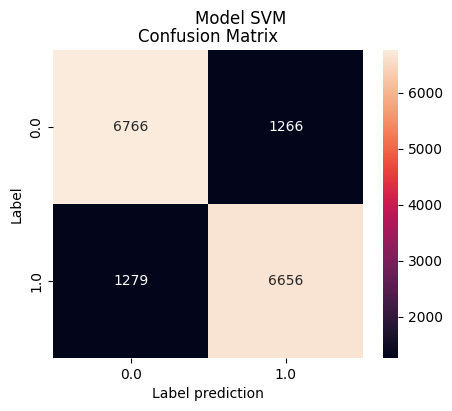

[Stage 1020:==========================================>             (3 + 1) / 4]

Performance metrics results: Support Vector Machine Model
Precision: 0.841 
Recall:    0.841 
Accuracy:  0.841 
f1Score:  0.841 


In [87]:
# Confusion Matrix is created
fifthModel = "Model SVM"
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotConfusionMat(confMatrixSVM, fifthModel)

# Metrics calculation
accuracySVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "accuracy"})
precisionSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedPrecision"})
recallSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "weightedRecall"})
f1ScoreSVM = evaluatorSVM.evaluate(predSVM, {evaluatorSVM.metricName: "f1"})

print(f"Performance metrics results: Support Vector Machine Model")
print(f"Precision: {round(precisionSVM,3)} ")
print(f"Recall:    {round(recallSVM,3)} ")
print(f"Accuracy:  {round(accuracySVM,3)} ")
print(f"f1Score:  {round(f1ScoreSVM,3)} ")

0.9149661043915077
areaUnderROC


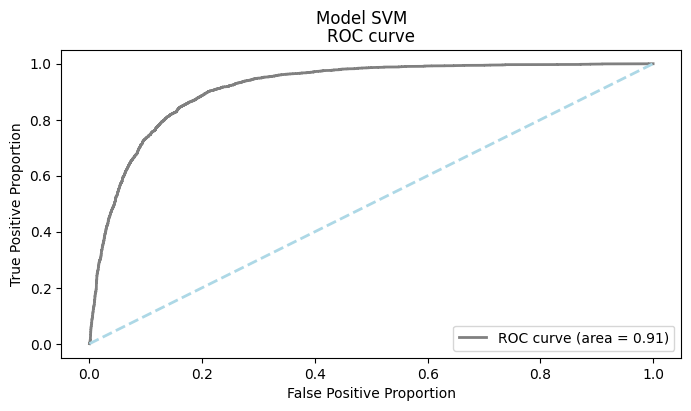

In [88]:
evaluatorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# ROC curve is calculated
rocSVM = evaluatorBinSVM.evaluate(predSVM)
print(rocSVM)
print(evaluatorBinSVM.getMetricName())

plotROC_SVM(predSVM,rocSVM,fifthModel)

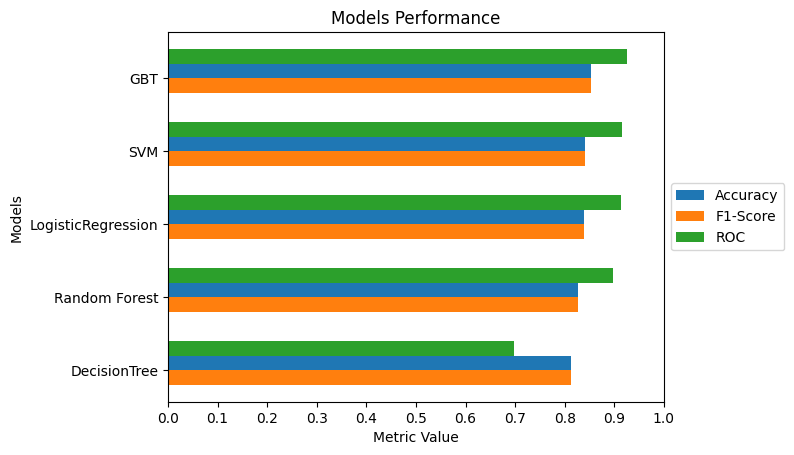

In [89]:
models  = ['LogisticRegression', 'DecisionTree', 'GBT','SVM', 'Random Forest' ]
accuracy = [accuracyLR, accuracyDT,accuracyGBT, accuracySVM, accuracyRF]
f1Score  = [f1ScoreLR, f1ScoreDT, f1ScoreGBT, f1ScoreSVM,f1ScoreRF]
ROCcurve = [rocLR, rocDT,rocGBT, rocSVM,rocRF]

# Values are ordered according to ROC
models, f1Score, accuracy, ROCcurve = zip(*sorted(zip(models, f1Score, accuracy, ROCcurve), key=lambda x: x[3]))

lenght = 0.2

# Posición de las barras en horizontal
posHorizontal = np.arange(len(models))

# Plotagem do gráfico de barras horizontais
barra1 = plt.barh(posHorizontal + 0.1, accuracy, lenght, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, lenght, label='F1-Score')
barra3 = plt.barh(posHorizontal + lenght + 0.1, ROCcurve, lenght, label='ROC')

# Configuración del gráfico
plt.ylabel('Models')
plt.xlabel('Metric Value')
plt.title('Models Performance')
plt.yticks(posHorizontal, models)
plt.xticks(np.arange(0, 1.1, 0.1))


# Se agregan las leyendas de métricas
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

# Se presenta el gráfico
plt.show()

# Conclusion
Throughout this document, all the fundamental and essential steps prior to creating a machine learning model were identified. Simultaneously, it is important to generate graphs that show the behavior of variables in relation to others, in order to make crucial decisions that will directly affect the models created subsequently. Finally, a proper analysis of the models and the appropriate selection of performance metrics, taking into account the results obtained, are fundamental. Furthermore, it is necessary to have a thorough understanding of the business context and objectives, in order to orient the model to meet them. It was identified that the best model in this case is the gradient boosted tree, obtaining values for all four performance metrics above 0.85 and having an area under the curve (AUC) of almost 0.93. Is suggested implement methods that reduce bias and define explicitly the bussiness objectives.

## References
One-Hot Encoding and Two-Hot Encoding: An Introduction. (2024). ResearchGate. https://OneHotEncoding.pdf